In [17]:
from _utils import *
from _regex_functions import *

In [18]:
raw_gpt_bl = pd.read_excel(GPT_DIR / "gpt_baseline_v1.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
raw_gpt_aug = pd.read_excel(GPT_DIR / "gpt_with_heuristics_v1.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
label_df = pd.read_csv(PIPELINE_DATA_DIR / "split_df2_with_labels.csv")

In [76]:
def clean_gpt(raw_gpt_df, label_df, annotated_samples, map_type):

    df = (
        raw_gpt_df
        .query("file_hash in @annotated_samples")
        .assign(gpt_pred_subtype=lambda df: df["gpt_pred_subtype"].str.split(","))
        .explode("gpt_pred_subtype")
    )

    df["gpt_pred_subtype"] = df["gpt_pred_subtype"].str.strip()

    df = (
        df
        .merge(label_df, how="left")
        .assign(gpt_pred_type=lambda df: df["gpt_pred_subtype"].apply(map_type))
        .groupby("file_hash", as_index=False)
        .agg(
            gpt_pred_subtype=("gpt_pred_subtype", lambda x: ", ".join(sorted(set(x)))),
            gpt_pred_type=("gpt_pred_type", lambda x: ", ".join(sorted(set(x))))
        )
        .merge(label_df, how="left")
        .query("set == 'test'")
        .assign(
            gpt_subtype_set=lambda df: df["gpt_pred_subtype"].apply(to_set),
            gpt_type_set=lambda df: df["gpt_pred_type"].apply(to_set),
            subtype_correct=lambda df: df.apply(
                lambda r: r["label"] in r["gpt_subtype_set"], axis=1
            ),
            type_correct=lambda df: df.apply(
                lambda r: r["type"] in r["gpt_type_set"], axis=1
            )
        )
        .rename(columns={"type": "true_type", "label": "true_subtype"})
    )

    return df


In [93]:
gpt_bl2 = clean_gpt(
    raw_gpt_df=raw_gpt_bl,
    label_df=label_df,
    annotated_samples=ANNOTATED_SAMPLES,
    map_type=map_type
)

gpt_aug2 = run_gpt_eval(
    raw_gpt_df=raw_gpt_aug,
    label_df=label_df,
    annotated_samples=ANNOTATED_SAMPLES,
    map_type=map_type
)


In [98]:
gpt_bl2.query("true_subtype == 'I Na (Slow inactivation)'")

,file_hash,gpt_pred_subtype,gpt_pred_type,true_type,true_subtype,set,gpt_subtype_set,gpt_type_set,subtype_correct,type_correct
503,70b9f203c1baf9aaee4d0fdbf643af166d2549c7a0f728...,"I Na (Slow inactivation), I Na (Transient)",I Na,I Na,I Na (Slow inactivation),test,"{I Na (Transient), I Na (Slow inactivation)}",{I Na},True,True
892,cd6648a125d09741daab4f669e7274422f3a4d5e5ee00b...,"I Na (Slow inactivation), I Na (Transient)",I Na,I Na,I Na (Slow inactivation),test,"{I Na (Transient), I Na (Slow inactivation)}",{I Na},True,True
962,dc48441a8ebd3a00422af29a1c7bc98c968447d624bba9...,"I Na (Slow inactivation), I Na (Transient)",I Na,I Na,I Na (Slow inactivation),test,"{I Na (Transient), I Na (Slow inactivation)}",{I Na},True,True


In [79]:
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [82]:
def for_single_label_plots(df, pred_col):
    """
    Keep rows where GPT predicted exactly one subtype
    (used ONLY for confusion matrices / classification report)
    """
    return df.loc[~df[pred_col].str.contains(",", na=False)].copy()


In [90]:
gpt_bl3 = for_single_label_plots(
    gpt_bl2,
    pred_col="gpt_pred_subtype"
)

gpt_aug3 = for_single_label_plots(
    gpt_aug2,
    pred_col="gpt_pred_subtype"
)


# GPT Baseline

GPT Type Accuracy: 0.9209

GPT Type Classification Report:
                   precision    recall  f1-score   support

             I Ca       1.00      0.97      0.99        36
              I H       1.00      0.75      0.86         8
     I H, I Other       0.00      0.00      0.00         0
              I K       1.00      0.99      0.99        74
        I K, I Na       0.00      0.00      0.00         0
    I K, Receptor       0.00      0.00      0.00         0
             I Na       1.00      1.00      1.00        36
          I Other       0.64      0.88      0.74         8
I Other, Receptor       0.00      0.00      0.00         0
          Neither       0.98      0.85      0.91        65
          R Other       0.00      0.00      0.00         0
         Receptor       0.88      0.81      0.84        26

         accuracy                           0.92       253
        macro avg       0.54      0.52      0.53       253
     weighted avg       0.97      0.92      0.94      

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


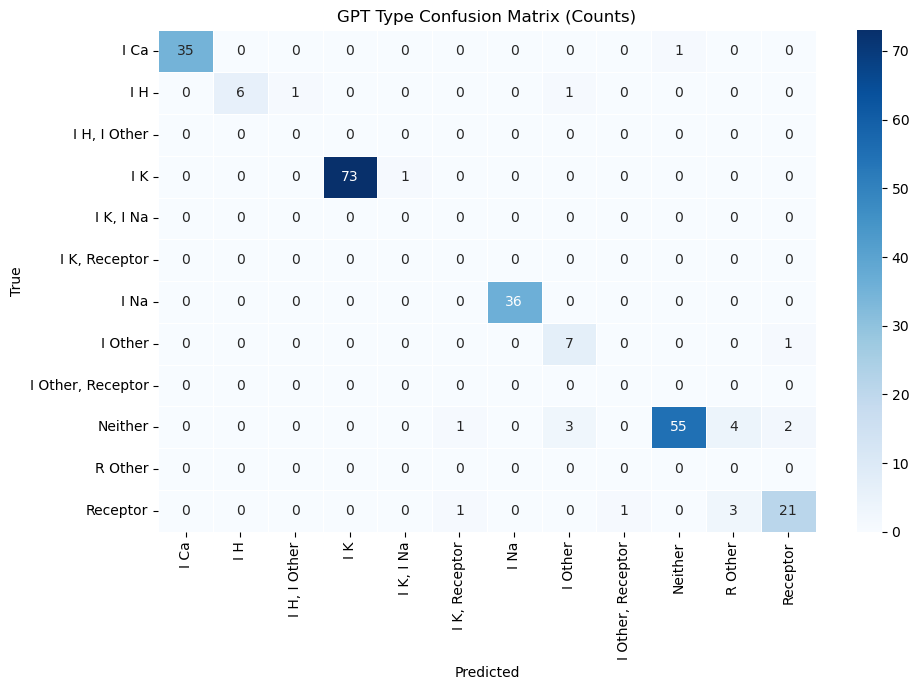

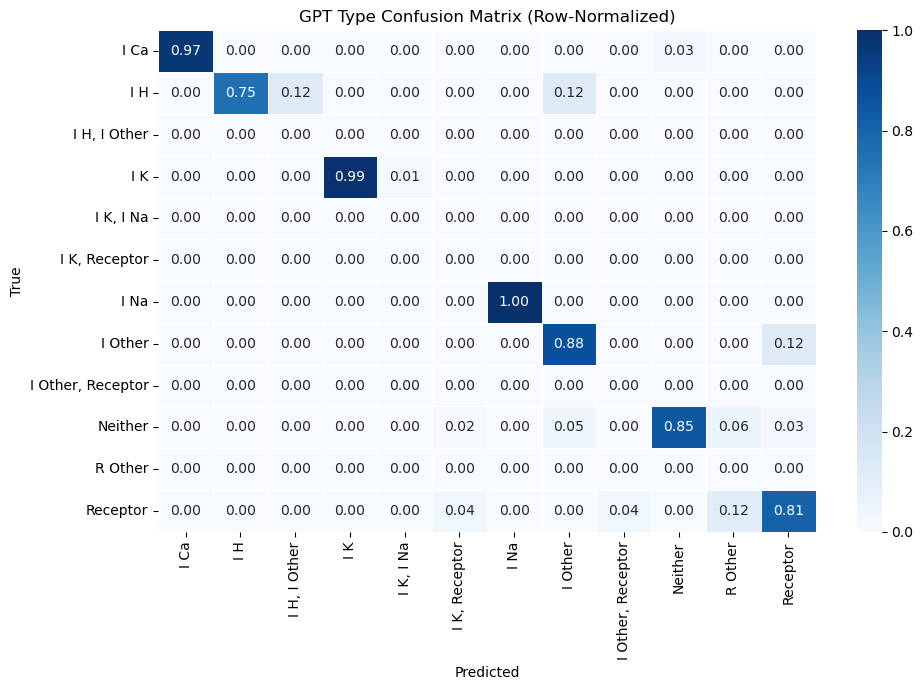


GPT Subtype Accuracy (Overall): 0.8340

GPT Subtype Classification Report (Overall):
                                            precision    recall  f1-score   support

                                I Ca (HVA)       0.90      0.86      0.88        22
                               I Ca (Rare)       0.00      0.00      0.00         3
                          I Ca (T-type LT)       1.00      1.00      1.00        11
                                       I H       1.00      0.75      0.86         8
                       I H, I Other (Rare)       0.00      0.00      0.00         0
                              I K (A-type)       1.00      0.89      0.94        19
                        I K (Ca-activated)       1.00      0.83      0.91        12
    I K (Ca-activated), R Glutamate (NMDA)       0.00      0.00      0.00         0
                   I K (Delayed Rectifier)       0.88      1.00      0.94        22
 I K (Delayed Rectifier), I Na (Transient)       0.00      0.00      0.00

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

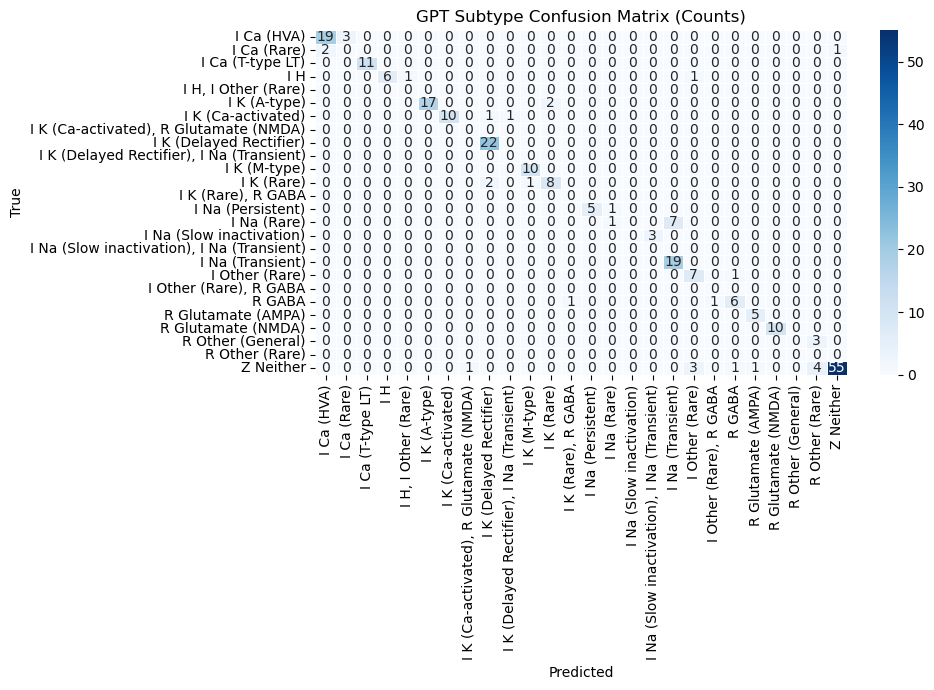

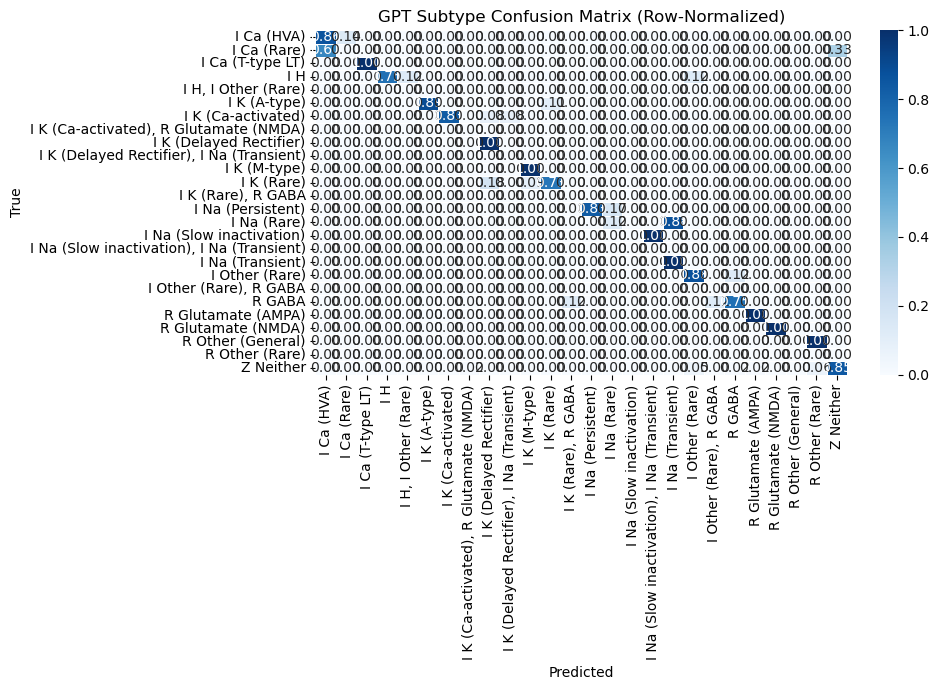

In [92]:


# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(gpt_bl2["true_type"], gpt_bl2["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    gpt_bl2["true_subtype"], gpt_bl2["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# GPT Heuristics

GPT Type Accuracy: 0.9328

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       1.00      0.97      0.99        36
         I H       1.00      1.00      1.00         8
         I K       0.99      1.00      0.99        73
        I Na       1.00      1.00      1.00        36
     I Other       0.75      0.75      0.75         8
     Neither       0.98      0.86      0.92        65
     R Other       0.00      0.00      0.00         0
    Receptor       0.92      0.88      0.90        25

    accuracy                           0.94       251
   macro avg       0.83      0.81      0.82       251
weighted avg       0.98      0.94      0.96       251



/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


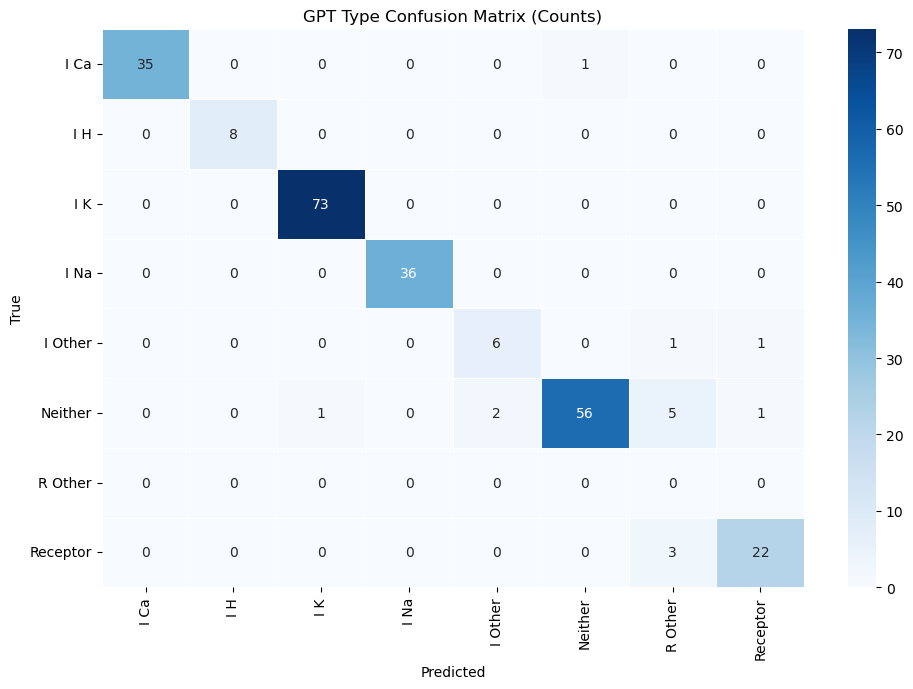

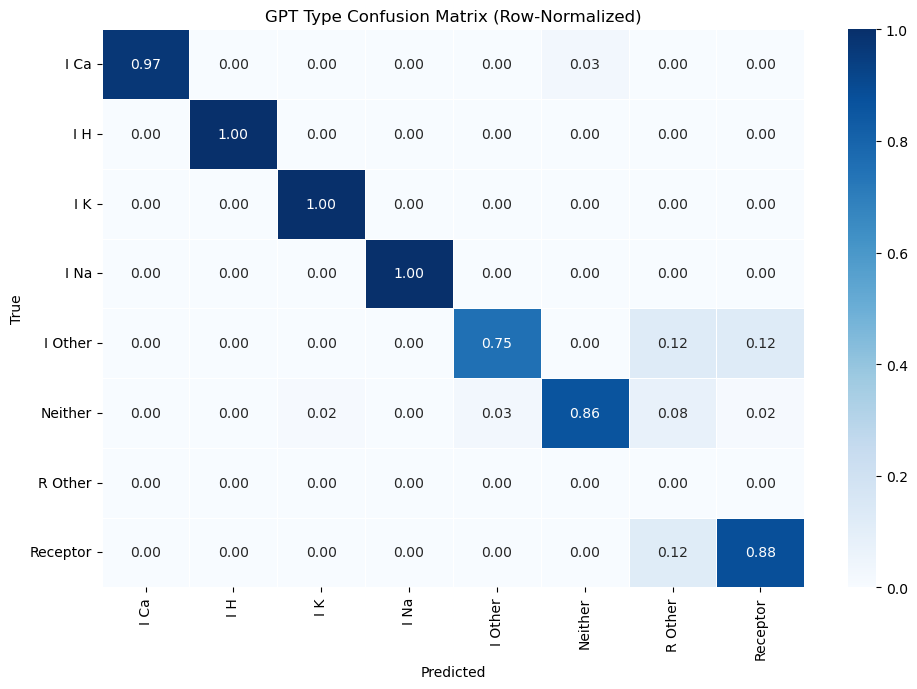


GPT Subtype Accuracy (Overall): 0.8775

GPT Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.88      1.00      0.94        22
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       1.00      0.91      0.95        11
                     I H       1.00      1.00      1.00         8
            I K (A-type)       1.00      0.95      0.97        19
      I K (Ca-activated)       0.91      0.91      0.91        11
 I K (Delayed Rectifier)       0.85      1.00      0.92        22
            I K (M-type)       1.00      1.00      1.00        10
              I K (Rare)       1.00      0.82      0.90        11
       I Na (Persistent)       1.00      1.00      1.00         6
             I Na (Rare)       1.00      0.12      0.22         8
I Na (Slow inactivation)       1.00      1.00      1.00         3
        I Na (Transient)       0.73      1.00      0.84

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

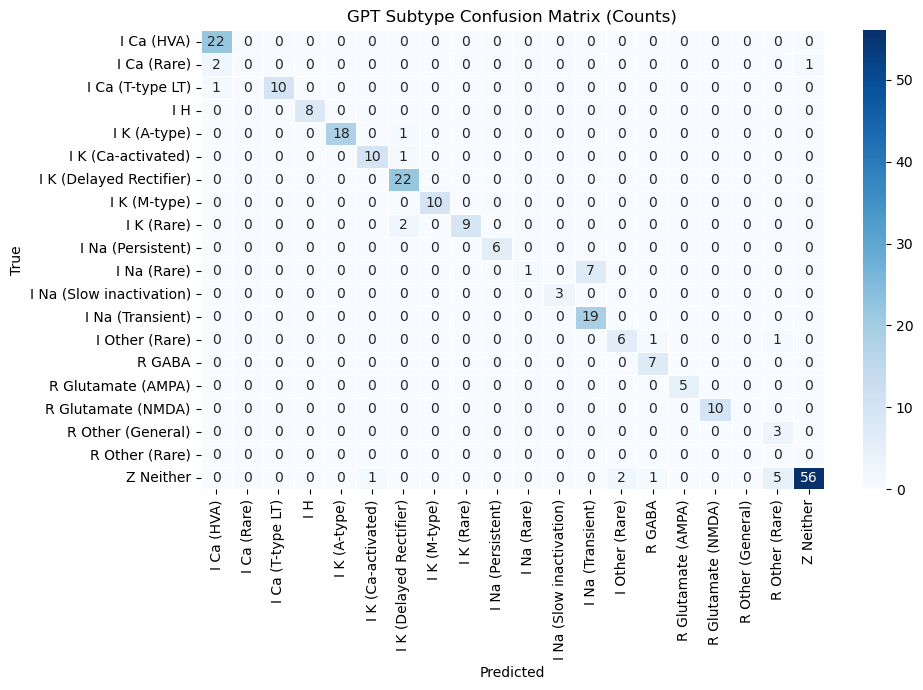

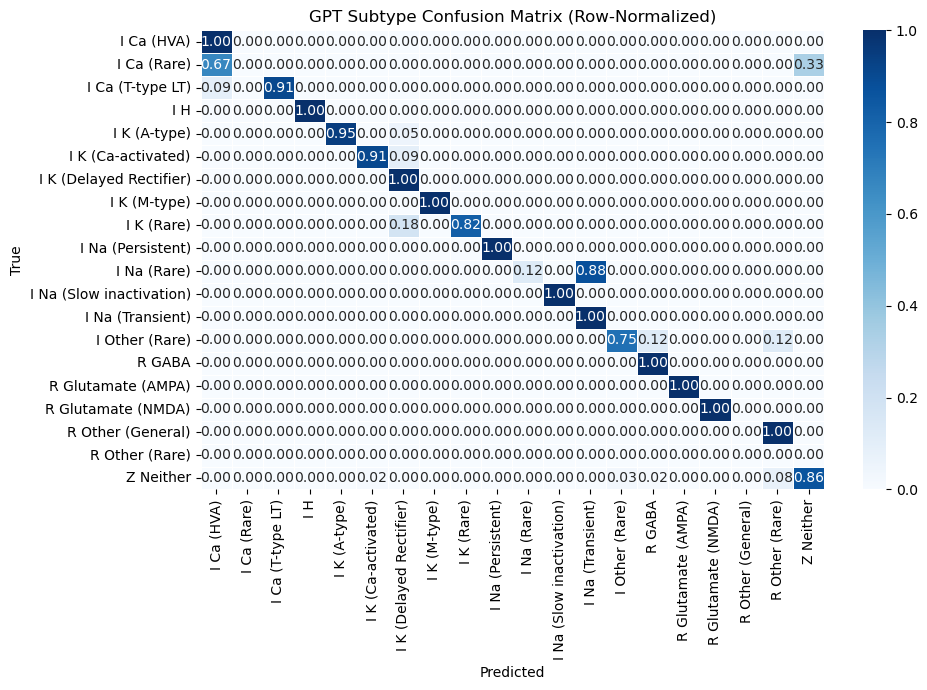

In [ ]:

# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(gpt_aug2["true_type"], gpt_aug2["gpt_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_pred_type"],
    title="GPT Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    gpt_aug2["true_subtype"], gpt_aug2["gpt_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)